In [1]:
import os
import sys
from pathlib import Path

# Get the project root directory (parent of notebooks folder)
project_root = str(Path(os.getcwd()).resolve().parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from tqdm import tqdm
import torch
import torch.optim as optim
import torch.nn as nn
# from torch.utils.data import Subset
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from torchsummary import summary

from src.load_data import CatDogDataLoadandSave, split_dataset
from models.vgg16 import VGG16
# from models.resnet import ResNetLayer
from src.data_classes import TrainingConfig
from src.train import Trainer

### data path 


In [2]:
data_path = r'/Users/gimoon/Documents/GitHub/Data'

### create dataset 

In [3]:
# CIFAR10 dataset
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    # transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Load from already downloaded dataset (set download=False)
# CIFAR-10 will be in data_path/cifar-10-batches-py/
dataset_train = datasets.CIFAR10(root=data_path, train=True, download=False, transform=transform)
dataset_test = datasets.CIFAR10(root=data_path, train=False, download=False, transform=transform)

print(f"Training samples: {len(dataset_train)}")
print(f"Test samples: {len(dataset_test)}")

/opt/miniconda3/envs/vgg16_with_py311/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 50000
Test samples: 10000


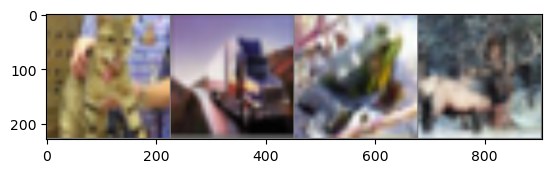

cat   truck frog  deer 


In [4]:
import numpy as np
import matplotlib.pyplot as plt

import torchvision
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

trainloader = DataLoader(dataset_train, batch_size=4, shuffle=True)

# 학습용 이미지를 무작위로 가져오기
dataiter = iter(trainloader)
images, labels = next(dataiter)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


NUM_CLASSES = len(classes)

# 이미지 보여주기
imshow(torchvision.utils.make_grid(images))
# 정답(label) 출력
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))


### Split dataset into training and validation sets, then create DataLoaders

In [14]:
train_dataset, val_dataset = split_dataset(dataset_train, train_ratio=0.8)

# Optional: Create subset for quick testing/debugging
USE_SUBSET = True  # Set to True for quick testing
SUBSET_SIZE = 10000  # Number of samples to use
BALANCED_SUBSET = True  # Set to True for balanced class distribution

if USE_SUBSET:
    from torch.utils.data import Subset
    import numpy as np
    
    if BALANCED_SUBSET:
        # Create balanced subset with equal samples per class
        num_classes = len(classes)
        samples_per_class = SUBSET_SIZE // num_classes
        
        # Collect indices for each class
        train_class_indices = {i: [] for i in range(num_classes)}
        for idx in range(len(train_dataset)):
            _, label = train_dataset[idx]
            train_class_indices[label].append(idx)
        
        # Sample equally from each class
        train_indices = []
        for class_idx in range(num_classes):
            class_samples = train_class_indices[class_idx][:samples_per_class]
            train_indices.extend(class_samples)
        
        # Do the same for validation
        val_samples_per_class = (SUBSET_SIZE // 5) // num_classes  # 20% of training subset
        val_class_indices = {i: [] for i in range(num_classes)}
        for idx in range(len(val_dataset)):
            _, label = val_dataset[idx]
            val_class_indices[label].append(idx)
        
        val_indices = []
        for class_idx in range(num_classes):
            class_samples = val_class_indices[class_idx][:val_samples_per_class]
            val_indices.extend(class_samples)
        
        print(f"Using BALANCED SUBSET mode:")
        print(f"  Samples per class: {samples_per_class} (train), {val_samples_per_class} (val)")
    else:
        # Unbalanced subset (just take first N samples)
        train_indices = list(range(min(SUBSET_SIZE, len(train_dataset))))
        val_indices = list(range(min(SUBSET_SIZE // 5, len(val_dataset))))
        print(f"Using UNBALANCED SUBSET mode:")
    
    train_dataset = Subset(train_dataset, train_indices)
    val_dataset = Subset(val_dataset, val_indices)
    print(f"  Train samples: {len(train_dataset)}")
    print(f"  Val samples: {len(val_dataset)}")



Training set size: 40000
Validation set size: 10000
Using BALANCED SUBSET mode:
  Samples per class: 1000 (train), 200 (val)
  Train samples: 10000
  Val samples: 2000


### Setting up training configuration 

In [15]:
# Configuration for training
config = TrainingConfig(
    batch_size=32,
    num_epochs=30,
    num_train_samples=len(train_dataset),  # Set from your dataset
    lr_scheduler_epoch=10,
    learning_rate=1e-4,
    weight_decay=1e-4,
    save_path=r"/Users/gimoon/Documents/GitHub/vgg16_practice/checkpoints"
)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")


Train batches: 313
Validation batches: 63


### load models

In [16]:
#Configure loss function, optimizer, and learning rate scheduler
if torch.backends.mps.is_available():    
    device = torch.device("mps")
    # Set MPS environment variables for performance tuning
    # Limit the number of threads used by MPS
    os.environ['MPS_NUM_THREADS'] = '4'  # Adjust based on your M-series chip (4, 8, or 10)
    print(f"Using device: {device}")
    print(f"MPS threads set to: {os.environ.get('MPS_NUM_THREADS', 'default')}")
else:
    device = torch.device("cpu")
    print(f"Using device: {device}")

# load model 
# model = VGG16(3, len(classes)).to(device)

Using device: mps
MPS threads set to: 4


In [17]:
# if device.type == 'cpu':
#     summary(model, (3, 224, 224))

### setting up for transfer learning 

In [18]:
from torchvision import models
model = models.vgg16(pretrained=True)

# freeze all layers first 
for param in model.parameters():
    param.requires_grad = False

# unfreeze the last layer of the classifier
model.classifier[3].requires_grad_ = True

# customize the last layer of the classifier to match the number of classes
model.classifier[6] = nn.Sequential(
                      nn.Linear(4096, 512), 
                      nn.ReLU(), 
                      nn.Dropout(0.5),
                      nn.Linear(512, NUM_CLASSES))

model = model.to(device)
model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)

### set loss criterion and optimizer 

In [19]:
# lr_scheduler_step_size = config.lr_scheduler_step_size()
# print(lr_scheduler_step_size)

total_steps = config.total_steps()
print(f"total number of steps: {total_steps}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
scheduler = StepLR(optimizer, step_size=config.lr_scheduler_step_size, gamma=0.5)

total number of steps: 9360


### Training 

In [20]:

def compute_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for features, labels in data_loader:
            features, labels = features.to(device), labels.to(device)
            logits = model(features)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total


def compute_epoch_loss(model, data_loader, criterion, device):
    model.eval()
    epoch_loss = 0
    num_examples = 0
    for features, labels in data_loader:
        features, labels = features.to(device), labels.to(device)
        logits = model(features)
        loss = criterion(logits, labels)
        epoch_loss += loss.item()
        num_examples += features.size(0)
    return epoch_loss / num_examples



for epoch in range(config.num_epochs):
    # ==================== TRAINING ====================
    model.train()
    epoch_train_loss = 0.0

    ProgressBar = tqdm(enumerate(train_loader), total=len(train_loader))

    for batch_idx, (inputs, labels) in ProgressBar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(inputs)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

        # Update Progress bar (only training loss during training)
        ProgressBar.set_description(f'Epoch [{epoch+1}/{config.num_epochs}]')
        ProgressBar.set_postfix(TrainLoss=loss.item())

    # Average training loss for the epoch
    avg_train_loss = epoch_train_loss / len(train_loader)

    # ==================== VALIDATION (Once per epoch) ====================
    print(f"\nRunning validation for epoch {epoch+1}...")
    with torch.no_grad():
        avg_val_acc = compute_accuracy(model, val_loader, device)
        avg_val_loss = compute_epoch_loss(model, val_loader, criterion, device)

    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f}")
    print(f"  Val Acc:    {avg_val_acc:.4f}")


Epoch [1/30]: 100%|██████████| 313/313 [02:03<00:00,  2.53it/s, TrainLoss=0.603]



Running validation for epoch 1...

Epoch 1 Summary:
  Train Loss: 1.2092
  Val Loss:   0.0250
  Val Acc:    0.7295


Epoch [2/30]: 100%|██████████| 313/313 [02:03<00:00,  2.54it/s, TrainLoss=0.877]



Running validation for epoch 2...

Epoch 2 Summary:
  Train Loss: 0.8293
  Val Loss:   0.0215
  Val Acc:    0.7610


Epoch [3/30]: 100%|██████████| 313/313 [02:01<00:00,  2.57it/s, TrainLoss=0.625]


...

Epoch [15/30]: 100%|██████████| 313/313 [02:00<00:00,  2.59it/s, TrainLoss=0.817]



Running validation for epoch 15...

Epoch 15 Summary:
  Train Loss: 0.5881
  Val Loss:   0.0174
  Val Acc:    0.7940


Epoch [16/30]: 100%|██████████| 313/313 [02:04<00:00,  2.52it/s, TrainLoss=0.703]



Running validation for epoch 16...


KeyboardInterrupt: 

In [39]:
test_loader = DataLoader(dataset_test, batch_size=config.batch_size, shuffle=False)

with torch.set_grad_enabled(False): # save memory during inference
    print('Test accuracy: %.2f%%' % (compute_accuracy(model, test_loader, device)*100))

Test accuracy: 78.76%


In [40]:
for batch_idx, (features, targets) in enumerate(test_loader):

    features = features
    targets = targets
    break

logits = model(features.to(device))
_, predicted_labels = torch.max(logits, 1)
    

In [42]:
features.shape

torch.Size([32, 3, 224, 224])

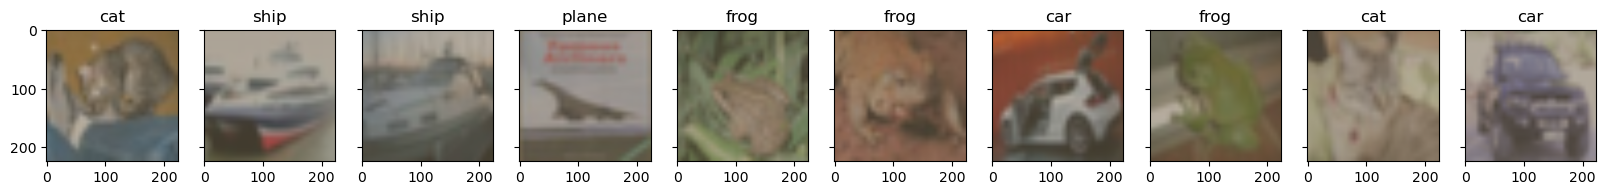

In [43]:
def unnormalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

n_images = 10

fig, axes = plt.subplots(nrows=1, ncols=n_images, 
                         sharex=True, sharey=True, figsize=(20, 2.5))
orig_images = features[:n_images]

for i in range(n_images):
    curr_img = orig_images[i].detach().to('cpu')
    curr_img = unnormalize(curr_img,
                           torch.tensor([0.485, 0.456, 0.406]),
                           torch.tensor([0.229, 0.224, 0.225])) 
    curr_img = curr_img.permute((1, 2, 0))
    axes[i].imshow(curr_img)
    axes[i].set_title(classes[predicted_labels[i]])